# PHASE 6 — ENCODING CATEGORICAL FEATURES

## Objectives:
1. **Explicit Ordinal Mapping:** Manually map ordinal categories (qualities, conditions, ratings) to explicit integers that preserve their true natural order (e.g., `Po` $\rightarrow$ 1, `Fa` $\rightarrow$ 2, `TA` $\rightarrow$ 3, `Gd` $\rightarrow$ 4, `Ex` $\rightarrow$ 5).
2. **Rare Category Bucketing:** Identify nominal categories with less than 1% frequency in the dataset and group them into an `"Other"` bucket to prevent sparse, noisy columns.
3. **Nominal One-Hot Encoding:** Apply `pd.get_dummies` to low/medium cardinality nominal variables (including `MSSubClass` converted to string).
4. **Export Cleaned Dataset:** Save the final encoded dataset as `train_processed_phase6.csv`.

## 🔑 Key Concepts

### 1. What Is Cardinality?

**Cardinality = Number of unique categories in a feature**

In [57]:
import pandas as pd
import numpy as np
import seaborn as sns
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Load the dataset saved from Phase 5 (Feature Engineering)
input_path = "../data/train_processed_phase5.csv"
df = pd.read_csv(input_path)

print(f"Phase 5 dataset loaded successfully. Shape: {df.shape}")

Phase 5 dataset loaded successfully. Shape: (1456, 83)


## Step 1: Explicit Ordinal Mapping

### Why Not Just Label Encode or One-Hot Encode Ordinals?
- **One-Hot Encoding** destroys the rank/order relationship between levels (e.g., `Ex` > `Gd` > `TA` > `Fa` > `Po`) and creates unnecessary extra columns.
- **Arbitrary Label Encoding** (like `cat.codes`) assigns integers based on alphabetical order (e.g., `Ex` becomes 0, `Fa` becomes 1), which distorts the true logical progression.

Here, we define explicit dictionaries mapping each rating level to its exact numeric value, ensuring missing values (`NA` / `None`) map safely to `0`.

In [58]:
# 1. Define explicit mapping dictionaries for ordinal features

# Standard 5-point quality/condition scale
qual_cond_map = {
    "Ex": 5, "Gd": 4, "TA": 3, "Fa": 2, "Po": 1, "NA": 0, "None": 0
}

# Basement Exposure
bsmt_exposure_map = {
    "Gd": 4, "Av": 3, "Mn": 2, "No": 1, "NA": 0, "None": 0
}

# Basement Finish Type (FinType1 & FinType2)
bsmt_fin_map = {
    "GLQ": 6, "ALQ": 5, "BLQ": 4, "Rec": 3, "LwQ": 2, "Unf": 1, "NA": 0, "None": 0
}

# Garage Interior Finish
garage_finish_map = {
    "Fin": 3, "RFn": 2, "Unf": 1, "NA": 0, "None": 0
}

# Paved Driveway
paved_drive_map = {
    "Y": 3, "P": 2, "N": 1
}

# Functional Rating
functional_map = {
    "Typ": 7, "Min1": 6, "Min2": 5, "Mod": 4, "Maj1": 3, "Maj2": 2, "Sev": 1, "Sal": 0
}

# Lot Shape
lot_shape_map = {
    "Reg": 4, "IR1": 3, "IR2": 2, "IR3": 1
}

# Land Slope
land_slope_map = {
    "Gtl": 3, "Mod": 2, "Sev": 1
}

# Fence Quality
fence_map = {
    "GdPrv": 4, "MnPrv": 3, "GdWo": 2, "MnWw": 1, "NA": 0, "None": 0
}

# Utilities
utilities_map = {
    "AllPub": 4, "NoSewr": 3, "NoSeWa": 2, "ELO": 1
}

# Group columns by mapping type
ordinal_mappings = {
    "OverallQual": {1:1, 2:2, 3:3, 4:4, 5:5, 6:6, 7:7, 8:8, 9:9, 10:10},
    "OverallCond": {1:1, 2:2, 3:3, 4:4, 5:5, 6:6, 7:7, 8:8, 9:9, 10:10},
    "ExterQual": qual_cond_map,
    "ExterCond": qual_cond_map,
    "BsmtQual": qual_cond_map,
    "BsmtCond": qual_cond_map,
    "HeatingQC": qual_cond_map,
    "KitchenQual": qual_cond_map,
    "FireplaceQu": qual_cond_map,
    "GarageQual": qual_cond_map,
    "GarageCond": qual_cond_map,
    "PoolQC": qual_cond_map,
    "BsmtExposure": bsmt_exposure_map,
    "BsmtFinType1": bsmt_fin_map,
    "BsmtFinType2": bsmt_fin_map,
    "GarageFinish": garage_finish_map,
    "PavedDrive": paved_drive_map,
    "Functional": functional_map,
    "LotShape": lot_shape_map,
    "LandSlope": land_slope_map,
    "Fence": fence_map,
    "Utilities": utilities_map
}
# Target column identification
target_col = "SalePrice_Log" if "SalePrice_Log" in df.columns else "SalePrice"

# Ensure integer-based nominals are string-typed before processing
if "MSSubClass" in df.columns:
    df["MSSubClass"] = df["MSSubClass"].astype(str)
    
# # Apply explicit ordinal mapping
for col, mapping in ordinal_mappings.items():
    if col in df.columns:
        # # Normalize case before mapping
        # df[col] = df[col].fillna('NA').astype(str).str.title()  # "ex" → "Ex"

        df[col] = df[col].map(mapping)

# 2. Fill any remaining NaNs (missing or unmapped) explicitly with 0
        df[col] = df[col].fillna(0).astype(int)

        
# # # ✅ Debug: Check for unmapped values
# for col in ordinal_mappings.keys():
#     if col in df.columns:
#         unique_vals = df[col].unique()
#         mapped_vals = df[col].map(ordinal_mappings[col]).isnull().sum()
#         if mapped_vals > 0:
#             print(f"⚠️ {col}: {mapped_vals} unmapped values: {unique_vals}")

print("✅ Explicit ordinal mapping complete!")

✅ Explicit ordinal mapping complete!


<Axes: xlabel='Condition2', ylabel='SalePrice'>

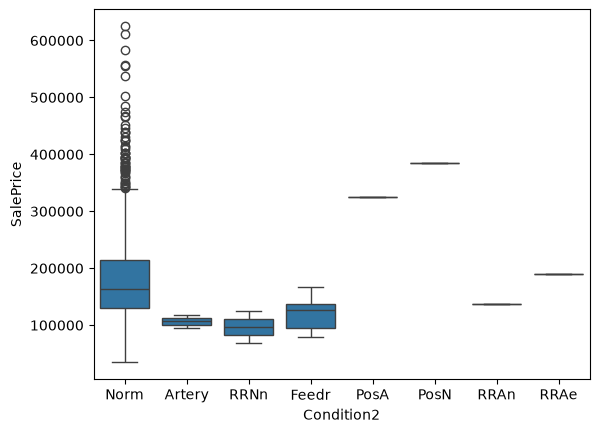

In [59]:
sns.boxplot(
        data=df, 
        x='Condition2', 
        y='SalePrice', 
        
        
        legend=False
    )


In [60]:
# sns.boxplot(
#         data=df, 
#         x='RoofMatl', 
#         y='SalePrice', 
#         # 
        
#         legend=False
#     )

### Step 2.1: Domain-Aware Custom Encoding for `Condition2`and other meainingful feature

when i do rare category bucketing on condition2 i get
✅ Condition2           → Bucketed  7 rare categories into 'Other'
while in other there is huge price diference btween categories in other.

#### Why Custom Bucketing for `Condition2`?
A standard 1% rare frequency threshold lumps all rare categories into a single `"Other"` bucket. For `Condition2`:
- **Positive Amenities** (`PosA`, `PosN`) represent parks/greenbelts and show a strong upward price boost (median price ~$325k–$385k).
- **Negative Disturbances** (`Artery`, `Feedr`, `RRNn`, `RRAn`, `RRAe`) represent heavy traffic or railroads and show a downward price penalty (median price ~$90k–$130k).

Combining them into a single `"Other"` category causes their opposite price effects to cancel out (~$0 net effect). We explicitly group them into **`Pos`**, **`Neg`**, and **`Norm`** to preserve clear directional signals for linear and tree-based models.


In [61]:
# List of nominal categorical columns
nominal_cols = [
    "MSSubClass", "MSZoning", "Street", "Alley", "LotConfig", "Neighborhood", 
    "Condition1", "Condition2", "BldgType", "HouseStyle", "RoofStyle", "RoofMatl", 
    "Exterior1st", "Exterior2nd", "MasVnrType", "Foundation", "Heating", 
    "CentralAir", "Electrical", "GarageType", "MiscFeature", "SaleType", 
    "SaleCondition", "LandContour"
]


# Define conditions present in either Condition1 or Condition2
def extract_condition_flags(df):
    
    cond1 = df['Condition1'].fillna('Norm').astype(str)
    cond2 = df['Condition2'].fillna('Norm').astype(str)
    
    # Positive off-site amenities (Park, Greenbelt, etc.)
    df['Has_Pos_Amenity'] = ((cond1.isin(['PosN', 'PosA'])) | (cond2.isin(['PosN', 'PosA']))).astype(int)
    
    # Street traffic disturbances
    df['Has_Traffic_Disturbance'] = ((cond1.isin(['Artery', 'Feedr'])) | (cond2.isin(['Artery', 'Feedr']))).astype(int)
    
    # Railroad noise disturbances
    df['Has_Railroad_Disturbance'] = ((cond1.isin(['RRNn', 'RRAn', 'RRNe', 'RRAe'])) | 
                                      (cond2.isin(['RRNn', 'RRAn', 'RRNe', 'RRAe']))).astype(int)
    
    # Drop raw columns after engineering
    df.drop(columns=['Condition1', 'Condition2'], inplace=True, errors='ignore')
    return df

df = extract_condition_flags(df)

# Remove from nominal_cols loop since they are now clean binary features
for col in ['Condition1', 'Condition2']:
    if col in nominal_cols:
        nominal_cols.remove(col)

print("✅ Successfully unified Condition1 & Condition2 into 3 binary impact features.")

✅ Successfully unified Condition1 & Condition2 into 3 binary impact features.


In [ ]:
print("=" * 80)
print("MSSUBCLASS ENCODING: BINARY/BIT ENCODING")
print("=" * 80)

if 'MSSubClass' in df.columns:
    # -------------------------------------------------------------------------
    # STEP 1: ASSIGN INTEGER CODES (0 TO 15) DIRECTLY TO NUMPY ARRAY
    # -------------------------------------------------------------------------
    unique_mssub = sorted(df['MSSubClass'].dropna().unique())
    mssub_to_code = {val: i for i, val in enumerate(unique_mssub)}
    
    # Convert directly to a raw NumPy integer array (bypasses Pandas Series type checks)
    mssub_codes = df['MSSubClass'].map(mssub_to_code).fillna(0).to_numpy(dtype=int)

    # -------------------------------------------------------------------------
    # STEP 2: EXTRACT BINARY BITS (2^4 = 16 >= 16 Unique Ames Categories)
    # -------------------------------------------------------------------------
    n_categories = len(unique_mssub)
    n_bits = 4 if n_categories <= 16 else int(np.ceil(np.log2(n_categories)))
    
    for bit in range(n_bits):
        # Bitwise shift and bitwise AND on native NumPy array
        df[f'MSSubClass_bit{bit}'] = (mssub_codes >> bit) & 1

    # -------------------------------------------------------------------------
    # STEP 3: CLEANUP RAW CATEGORICAL COLUMN
    # -------------------------------------------------------------------------
    df.drop(columns=['MSSubClass'], inplace=True)

    print(f"✅ Successfully encoded {n_categories} categories into {n_bits} binary bit columns.")
    print(f"✅ Created features: " + ", ".join([f'MSSubClass_bit{i}' for i in range(n_bits)]))
else:
    print("⚠️ 'MSSubClass' column not found in DataFrame.")

ValueError: invalid literal for int() with base 10: 'Other'

In [63]:
# =============================================================================
# DOMAIN FEATURE REDUCTION (PREVENTING HIGH-CARDINALITY ONE-HOT OVERFITTING)
# =============================================================================

print("=" * 80)
print("DOMIAN REDUCTIONS: Transforming Sparse Nominals to High-Signal Features")
print("=" * 80)

# 1. Heavy Dominance Binary Flags (>98% single category)
if 'RoofMatl' in df.columns:
    df['Is_Standard_Roof'] = (df['RoofMatl'] == 'CompShg').astype(int)
    print("✅ Created 'Is_Standard_Roof' (replaced RoofMatl)")

if 'Heating' in df.columns:
    df['Is_GasA_Heating'] = (df['Heating'] == 'GasA').astype(int)
    print("✅ Created 'Is_GasA_Heating' (replaced Heating)")

# 2. Convert HouseStyle into Numerical Stories & Split Layout Flag
if 'HouseStyle' in df.columns:
    style_story_map = {
        '1Story': 1.0, '1.5Unf': 1.25, '1.5Fin': 1.5, 
        '2Story': 2.0, '2.5Unf': 2.25, '2.5Fin': 2.5,
        'SFoyer': 1.5, 'SLvl': 1.5
    }
    df['HouseStyle_Stories'] = df['HouseStyle'].map(style_story_map).fillna(1.0)
    df['Is_Split_Layout'] = df['HouseStyle'].isin(['SFoyer', 'SLvl']).astype(int)
    print("✅ Extracted 'HouseStyle_Stories' and 'Is_Split_Layout' (replaced HouseStyle)")

# 3. Transaction Context Consolidation (SaleType & SaleCondition)
if 'SaleType' in df.columns and 'SaleCondition' in df.columns:
    df['Is_New_Construction'] = ((df['SaleType'] == 'New') | (df['SaleCondition'] == 'Partial')).astype(int)
    df['Is_Distressed_Sale'] = df['SaleCondition'].isin(['Abnorml', 'AdjLand', 'Alloca']).astype(int)
    df['Is_Normal_Sale'] = ((df['SaleCondition'] == 'Normal') & (df['SaleType'] != 'New')).astype(int)
    print("✅ Consolidated SaleType/SaleCondition into 'Is_New_Construction', 'Is_Distressed_Sale', 'Is_Normal_Sale'")

# # 4. Extract PUD status from MSSubClass
# if 'MSSubClass' in df.columns:
#     pud_codes = [120, 150, 160, 180, '120', '150', '160', '180']
#     df['Is_PUD'] = df['MSSubClass'].isin(pud_codes).astype(int)
#     print("✅ Extracted 'Is_PUD' from MSSubClass")

# 5. REMOVE TRANSFORMED COLUMNS FROM nominal_cols
# This prevents pd.get_dummies from creating sparse/redundant one-hot columns later
cols_to_remove = ['RoofMatl', 'Heating', 'HouseStyle', 'SaleType', 'SaleCondition']
nominal_cols = [col for col in nominal_cols if col not in cols_to_remove]
# 
# Clean up original dataframes columns
df = df.drop(columns=[col for col in cols_to_remove if col in df.columns])

print(f"\n✅ Cleaned nominal_cols list. Remaining features to be One-Hot Encoded: {len(nominal_cols)}")

DOMIAN REDUCTIONS: Transforming Sparse Nominals to High-Signal Features
✅ Created 'Is_Standard_Roof' (replaced RoofMatl)
✅ Created 'Is_GasA_Heating' (replaced Heating)
✅ Extracted 'HouseStyle_Stories' and 'Is_Split_Layout' (replaced HouseStyle)
✅ Consolidated SaleType/SaleCondition into 'Is_New_Construction', 'Is_Distressed_Sale', 'Is_Normal_Sale'

✅ Cleaned nominal_cols list. Remaining features to be One-Hot Encoded: 17


## Step 2.2: Rare Category Bucketing (< 1% Frequency)

### Why Bucket Rare Categories?
High-cardinality nominal variables like `Neighborhood`, `Exterior1st`, or `RoofMatl` contain rare categories that appear only once or twice in the dataset. 
- If one-hot encoded directly, they create **extremely sparse columns** that add noise and cause models to overfit.
- Any category representing less than 1% of total observations is bucketed into `"Other"`.
- We also ensure numeric nominal codes like `MSSubClass` are converted to `str` so they aren't treated as continuous numbers.

In [64]:
# 2. Exclude Neighborhood from rare bucketing so Target Encoding preserves all 28 location signals
rare_loop_cols = [col for col in nominal_cols if col != "Neighborhood"]

THRESHOLD = 0.01  # 1% frequency threshold

for col in rare_loop_cols:
    if col in df.columns:
        df[col] = df[col].fillna("Missing").astype(str)
        freq = df[col].value_counts(normalize=True)
        rare_levels = freq[freq < THRESHOLD].index
        
        if len(rare_levels) > 0:
            print(f"✅ {col:20s} → Bucketed {len(rare_levels):2d} rare categories into 'Other'")
            df[col] = df[col].replace(rare_levels, "Other")

# Add Condition2 back to the list of nominals so get_dummies processes it
if 'Condition2' in df.columns and 'Condition2' not in nominal_cols:
    nominal_cols.append('Condition2')

if 'MSSubClass' in df.columns and 'MSSubClass' not in nominal_cols:
    nominal_cols.append('MSSubClass')

print("✅ Rare category bucketing complete!")

✅ MSSubClass           → Bucketed  3 rare categories into 'Other'
✅ MSZoning             → Bucketed  1 rare categories into 'Other'
✅ Street               → Bucketed  1 rare categories into 'Other'
✅ LotConfig            → Bucketed  1 rare categories into 'Other'
✅ RoofStyle            → Bucketed  4 rare categories into 'Other'
✅ Exterior1st          → Bucketed  5 rare categories into 'Other'
✅ Exterior2nd          → Bucketed  6 rare categories into 'Other'
✅ Foundation           → Bucketed  2 rare categories into 'Other'
✅ Electrical           → Bucketed  3 rare categories into 'Other'
✅ GarageType           → Bucketed  2 rare categories into 'Other'
✅ MiscFeature          → Bucketed  3 rare categories into 'Other'
✅ Rare category bucketing complete!


### 🏘️ Neighborhood Encoding:  — Unsupervised K-Means Clustering+ one hot 

**The Concept**
Instead of using `SalePrice` (which causes target leakage) or manually guessing neighborhood tiers, Solution 5 uses an **unsupervised machine learning algorithm (K-Means)** to group neighborhoods based on their physical "fingerprints." 

**Why K-Means is Unsupervised**
K-Means operates strictly on non-target physical features ($X$) without ever seeing `SalePrice` ($y$). It measures spatial Euclidean distance in multi-dimensional feature space to group structurally similar neighborhoods.

**How Centroids Work & Convergence**
1. **Physical Fingerprint:** We collapse the dataset to calculate each neighborhood's median physical attributes (`LotArea`, `YearBuilt`, `OverallQual`, `GrLivArea`).
2. **Centroid Initialization:** K-Means places $K=5$ center points (centroids) into this 4D physical space.
3. **Assignment & Movement:** Each neighborhood joins its nearest centroid. The centroid then moves to the exact mathematical average (**mean**) of all neighborhood coordinates in its group.
4. **Convergence (Freeze):** This loop repeats until centroids stop moving and group boundaries freeze.

**Why One-Hot Encoding the Clusters is Required**
K-Means outputs raw cluster numbers (`0`, `1`, `2`, `3`, `4`). Because these numbers are arbitrary nominal group IDs—not numerical rankings—we apply `pd.get_dummies(drop_first=True)` to create binary indicators. 

**How the Downstream Model Learns "Luxury" vs. "Budget"**
* **K-Means** groups high-end physical traits together (e.g., `OverallQual` $\approx 8$, `GrLivArea` $\ge 1800$, `YearBuilt` $\ge 2000$).
* **One-Hot Encoding** creates binary flags like `NbhdClust_4 = 1`.
* **Supervised Model** (Ridge/XGBoost) sees properties with `NbhdClust_4 = 1` consistently selling for high prices during training and automatically assigns a large positive price coefficient ($\beta$).

---

In [65]:


print("=" * 80)
print("NEIGHBORHOOD ENCODING: SOLUTION 3 (BINARY/BIT ENCODING)")
print("=" * 80)

if 'Neighborhood' in df.columns:
    # -------------------------------------------------------------------------
    # STEP 1: ASSIGN INTEGER CODES (0 TO 24) DIRECTLY TO NUMPY ARRAY
    # -------------------------------------------------------------------------
    unique_nbhds = sorted(df['Neighborhood'].dropna().unique())
    nbhd_to_code = {name: i for i, name in enumerate(unique_nbhds)}
    
    # Convert directly to a raw NumPy integer array (bypasses Pandas Series type checks)
    nbhd_codes = df['Neighborhood'].map(nbhd_to_code).fillna(0).to_numpy(dtype=int)

    # -------------------------------------------------------------------------
    # STEP 2: EXTRACT BINARY BITS (2^5 = 32 >= 25 Categories)
    # -------------------------------------------------------------------------
    n_bits = 5  # 5 bits cover up to 32 unique categories
    
    for bit in range(n_bits):
        # Bitwise shift and bitwise AND on native NumPy array
        df[f'Nbhd_bit{bit}'] = (nbhd_codes >> bit) & 1

    # -------------------------------------------------------------------------
    # STEP 3: CLEANUP RAW CATEGORICAL COLUMN
    # -------------------------------------------------------------------------
    df.drop(columns=['Neighborhood'], inplace=True)

    print("✅ Successfully encoded 25 categories into 5 binary bit columns.")
    print("✅ Created features: Nbhd_bit0, Nbhd_bit1, Nbhd_bit2, Nbhd_bit3, Nbhd_bit4.")
else:
    print("⚠️ 'Neighborhood' column not found in DataFrame.")

    

NEIGHBORHOOD ENCODING: SOLUTION 3 (BINARY/BIT ENCODING)
✅ Successfully encoded 25 categories into 5 binary bit columns.
✅ Created features: Nbhd_bit0, Nbhd_bit1, Nbhd_bit2, Nbhd_bit3, Nbhd_bit4.


## Step 3: One-Hot Encoding Nominal Features

Now that rare categories are combined, we perform one-hot encoding on all nominal features. 
We set `drop_first=True` to eliminate multi-collinearity (the dummy variable trap) for linear models.

In [66]:
 

# Identify existing nominal columns in the dataframe (Neighborhood already handled in Step 2)
existing_nominals = [col for col in nominal_cols if col in df.columns]
print(f"nominal_cols that are going to hot encoding:{existing_nominals}")
# ---- One-Hot Encode the low-cardinality columns ----
df_encoded = pd.get_dummies(df, columns=existing_nominals, drop_first=True, dtype=int)

print(f"\nOriginal shape before encoding: {df.shape}")
print(f"Encoded shape after hybrid encoding: {df_encoded.shape}")


nominal_cols that are going to hot encoding:['MSSubClass', 'MSZoning', 'Street', 'Alley', 'LotConfig', 'BldgType', 'RoofStyle', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'Foundation', 'CentralAir', 'Electrical', 'GarageType', 'MiscFeature', 'LandContour']

Original shape before encoding: (1456, 90)
Encoded shape after hybrid encoding: (1456, 144)


## Step 4: Save Phase 6 Dataset

Save the fully encoded dataframe so it can be loaded directly into your model training script for Random Forest and XGBoost.

In [67]:
output_path = "../data/train_processed_phase6.csv"
df_encoded.to_csv(output_path, index=False)

print(f"Phase 6 Complete! Successfully exported encoded dataset to '{output_path}'")
print(f"Total Columns: {df_encoded.shape[1]}")


Phase 6 Complete! Successfully exported encoded dataset to '../data/train_processed_phase6.csv'
Total Columns: 144
